Here, we see how our loss changes as a function of the various hyperparameters we were interested in:

In [1]:
import os

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(1, '../.')
from Kang_utils import get_best_hyperparams

In [2]:
seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'


In [27]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)

In [28]:
best_emd_mean

,,,emd_loss_total
max_epochs,max_lr,train_batch_size,
900.0,0.0001,512.0,235.129729


In [29]:
best_emd

,max_epochs,max_lr,train_batch_size,k,emd_loss_total,KL_regularization
145,900.0,0.0001,512.0,0.0,237.651009,0.01
146,900.0,0.0001,512.0,1.0,235.613094,0.02
147,900.0,0.0001,512.0,2.0,244.175056,0.01
148,900.0,0.0001,512.0,3.0,205.066906,0.02
149,900.0,0.0001,512.0,4.0,253.142578,0.01


''

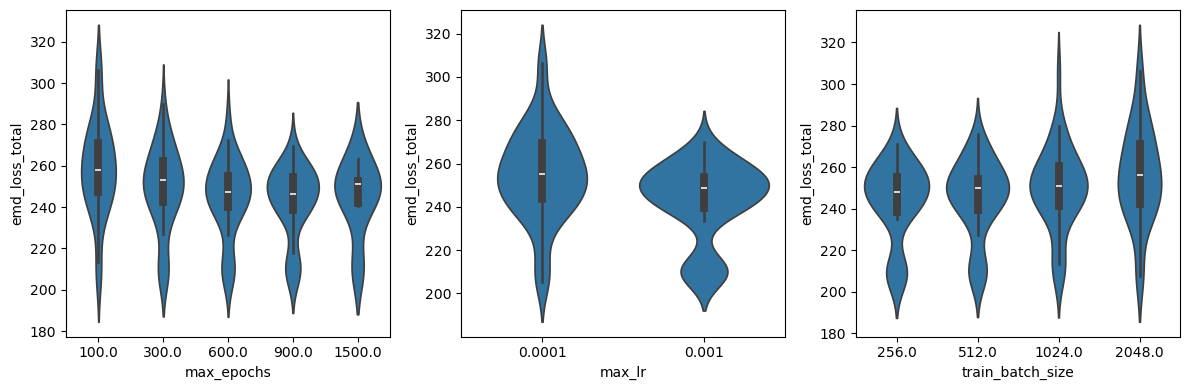

In [8]:
fig, ax = plt.subplots(figsize = (12, 4), ncols = 3)

sns.violinplot(data = res, x = 'max_epochs', y = 'emd_loss_total', ax = ax[0])
sns.violinplot(data = res, x = 'max_lr', y = 'emd_loss_total', ax = ax[1])
sns.violinplot(data = res, x = 'train_batch_size', y = 'emd_loss_total', ax = ax[2])
fig.tight_layout()
;

<Axes: xlabel='max_epochs', ylabel='max_lr'>

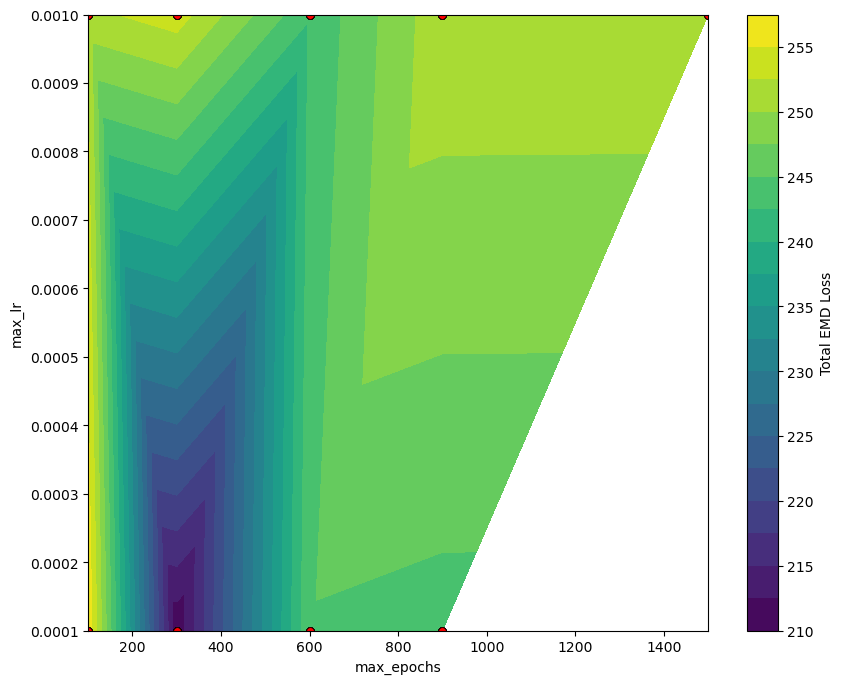

In [15]:
plt.figure(figsize=(10, 8))
viz_df = res[res.emd_loss_total.notna()]
x = viz_df.max_epochs
y = viz_df.max_lr
z = viz_df.emd_loss_total

contour = plt.tricontourf(x, y, z, levels=20, cmap="viridis")
plt.colorbar(contour, label="Total EMD Loss")

# Add scatter plot of the points for reference
sns.scatterplot(x=x, y=y, color='red', s=30, edgecolor='black')
